In [ ]:
import os
import sys
import time
import errno

import numpy as np
import scipy as scp
import pandas as pd
#import seaborn as sns

In [2]:
import torch
import sbi

import sbi.inference
from sbi.inference import SNPE, prepare_for_sbi ,simulate_for_sbi, DirectPosterior
from sbi.inference.base import infer

from sbi.analysis import ActiveSubspace, pairplot
import sbi.utils as utils

/home/prior/anaconda3/envs/sbipy310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from typing import Any, Callable, Dict, List, Optional, Tuple, Union, cast

In [4]:
import warnings
warnings.filterwarnings("ignore")

## Loading and plotting the features

In [5]:

theta_and_features_df = pd.read_csv('/home/prior/gp_home/vbt-synthetic-patient/results/jdopa_ws_more_sigma_sweep_extracted_features.csv', index_col=0)
print(theta_and_features_df.shape)
selected_params = ['njdopa_ctx', 'njdopa_str', 'ws']
theta_and_features_df[selected_params] = np.log10(theta_and_features_df[selected_params])

(1331, 75)


In [6]:
theta_and_features_df.describe()

,GBC,VAR_FCD,ws,njdopa_ctx,njdopa_str,L.PU_FC,L.CA_FC,L.HI_FC,L.STG_FC,L.CER_FC,...,R.HI_ALFF,R.STG_ALFF,R.CER_ALFF,R.CACG_ALFF,R.RACG_ALFF,R.IN_ALFF,R.PCG_ALFF,R.POP_ALFF,R.POR_ALFF,R.PTR_ALFF
count,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,...,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000
mean,0.100579,0.002447,-1.001644,-1.001644,-1.001644,0.067038,0.063981,0.047201,0.056654,0.022138,...,-0.225566,-0.155820,-0.619332,0.029971,0.276683,0.042382,0.167593,-0.012776,-0.123790,1.841551
std,0.053876,0.001957,1.734370,1.734370,1.734370,0.039529,0.025566,0.021539,0.042249,0.013036,...,0.479786,1.042801,0.705067,0.609723,0.855972,0.827460,1.101005,0.662021,0.984312,1.155789
min,0.034267,0.000407,-4.000000,-4.000000,-4.000000,-0.025441,0.016001,0.003700,0.006907,-0.014132,...,-1.531149,-1.487153,-2.107338,-1.417444,-1.651297,-1.448745,-1.564088,-1.730276,-1.556929,-0.569937
25%,0.054326,0.000927,-2.522879,-2.522879,-2.522879,0.032418,0.041634,0.032077,0.023111,0.013542,...,-0.589277,-1.062088,-1.240374,-0.473769,-0.502476,-0.834146,-0.815457,-0.562024,-0.830194,0.892827
50%,0.087351,0.001596,-1.000000,-1.000000,-1.000000,0.066564,0.063326,0.041227,0.042704,0.021496,...,-0.150985,-0.548672,-0.449607,-0.003834,0.150470,0.292838,-0.386190,-0.080583,-0.558442,1.807114
75%,0.134051,0.003454,0.499962,0.499962,0.499962,0.092148,0.077527,0.060334,0.089360,0.029888,...,0.102259,0.688882,-0.009657,0.630909,1.057969,0.860144,1.392430,0.458534,0.523605,2.595626
max,0.243023,0.009386,2.000000,2.000000,2.000000,0.158978,0.130998,0.124764,0.171060,0.073149,...,0.874193,1.965012,0.436763,1.253080,2.288837,1.122841,1.954163,2.033141,2.902433,5.027443


In [7]:
theta_and_features_df.max()

GBC           0.243023
VAR_FCD       0.009386
ws            2.000000
njdopa_ctx    2.000000
njdopa_str    2.000000
                ...   
R.IN_ALFF     1.122841
R.PCG_ALFF    1.954163
R.POP_ALFF    2.033141
R.POR_ALFF    2.902433
R.PTR_ALFF    5.027443
Length: 75, dtype: float64

In [8]:
print(np.any(theta_and_features_df.values == np.inf))
print(np.any(theta_and_features_df.values == np.nan))

False
False


In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(theta_and_features_df)

## Selecting and normalizing the features

There is actually no need for normalizing the synthetic features as it is authomatically done. It is very important that you will have the empirical and synthetic data in same format. 

In [10]:
selected_params = ['njdopa_ctx', 'njdopa_str', 'ws']

datafeat_df = train_df.drop(columns=selected_params)
print(datafeat_df.shape)

theta_df = train_df[selected_params]
print(theta_df.shape)

(998, 72)
(998, 3)


## Preparing params and features for SBI

In [11]:
datafeat = datafeat_df.values
theta = theta_df.values
print(datafeat.dtype, theta.dtype)
print(datafeat.shape, theta.shape)

float64 float64
(998, 72) (998, 3)


In [12]:
x = np.array(datafeat, dtype='float32')
x = torch.as_tensor(x)

theta = np.array(theta, dtype='float32')
theta = theta.reshape(theta.shape[0],len(selected_params))
theta = torch.as_tensor(theta)

In [13]:
print( 'theta shape:',theta.shape,flush=True)
print('data feature shape:', x.shape,flush=True)
print(theta.isnan().any())
print(x.isnan().any())

theta shape: torch.Size([998, 3])
data feature shape: torch.Size([998, 72])
tensor(False)
tensor(False)


In [14]:
prior_min = [theta_and_features_df['njdopa_ctx'].min(), theta_and_features_df['njdopa_str'].min(), theta_and_features_df['ws'].min()]
prior_max = [theta_and_features_df['njdopa_ctx'].max(), theta_and_features_df['njdopa_str'].max(), theta_and_features_df['ws'].max()]
prior = utils.torchutils.BoxUniform(low=torch.as_tensor(prior_min), high=torch.as_tensor(prior_max)) # perhaps different distributions log or gaussian
num_params=prior.sample().shape[0]
num_params

3

## Running SBI 

In [15]:
inference = SNPE(prior, density_estimator='maf', device='cpu')

In [16]:
start_time = time.time()

posterior_estimator = inference.append_simulations(theta, x).train()

print ("-"*60)
print("---training took:  %s seconds ---" % (time.time() - start_time))

 Neural network successfully converged after 98 epochs.------------------------------------------------------------
---training took:  20.758058547973633 seconds ---


In [17]:
posterior = DirectPosterior(posterior_estimator, prior,) 

In [18]:
test_datafeat_df = test_df.drop(columns=selected_params)
print(test_datafeat_df.shape)

test_theta_df = test_df[selected_params]
print(test_theta_df.shape)

(333, 72)
(333, 3)


In [20]:
test_datafeat_df

,GBC,VAR_FCD,L.PU_FC,L.CA_FC,L.HI_FC,L.STG_FC,L.CER_FC,L.CACG_FC,L.RACG_FC,L.IN_FC,...,R.HI_ALFF,R.STG_ALFF,R.CER_ALFF,R.CACG_ALFF,R.RACG_ALFF,R.IN_ALFF,R.PCG_ALFF,R.POP_ALFF,R.POR_ALFF,R.PTR_ALFF
149,0.084464,0.001681,0.073932,0.070712,0.044961,0.040434,0.028107,0.009582,0.010539,0.054498,...,-0.443597,-0.890487,-1.570371,-0.092932,-0.548711,-1.417446,-0.674730,-1.022148,-0.459277,0.861898
262,0.046255,0.000875,0.031857,0.040376,0.034196,0.015274,0.022889,0.030273,0.027522,0.033633,...,-0.036058,0.461819,0.003406,0.619019,1.011194,0.812298,1.506574,0.401162,-0.902489,3.841061
838,0.045581,0.000844,0.023877,0.036696,0.030912,0.011828,0.023557,0.026578,0.031895,0.029860,...,-0.056818,0.476763,0.197038,0.697243,0.940904,0.972337,1.805261,0.426717,-0.938815,3.595797
1079,0.150042,0.003023,0.113682,0.106074,0.069091,0.063113,0.037693,0.041471,0.050678,0.099504,...,-0.371211,-1.319543,-0.745631,-0.014593,-0.289709,-1.339898,-1.353178,0.165237,1.478115,0.667496
1063,0.085574,0.001077,0.064367,0.058503,0.034680,0.039796,0.036841,0.016613,0.031288,0.049875,...,-0.261583,-0.560222,-1.800182,-0.674302,-0.687216,-0.902833,-0.554740,-0.374878,-0.276955,1.318258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.149087,0.004640,-0.018737,0.039363,0.077545,0.103710,0.023843,0.048299,0.032787,0.103525,...,-0.418343,0.109098,-0.379852,1.019568,0.762578,0.709744,1.215007,0.446827,1.159323,1.675931
1293,0.225000,0.007604,0.109442,0.089125,0.090425,0.161828,0.025567,0.077563,0.060879,0.141396,...,-1.078198,-0.180773,-0.646147,-0.385075,0.588403,0.457565,0.039467,0.409743,-0.779140,0.305702
276,0.039431,0.000584,0.013781,0.033473,0.023796,0.013766,0.033362,0.021160,0.022594,0.024271,...,0.425821,1.343289,0.368363,0.765778,1.137328,0.959890,1.418836,-0.099177,-0.602930,2.771111
1126,0.154616,0.003745,0.113622,0.071737,0.042981,0.103892,0.006676,0.057256,0.044175,0.072745,...,-0.457122,-1.317525,-1.025886,-0.505978,-1.136648,-0.322164,-1.237468,0.228068,0.795103,0.658110


In [33]:
n = 1293
x_obs_summary_statistics = test_datafeat_df.loc[n]
true_params = test_theta_df.loc[n]
njdopa_ctx_true = true_params[0]
njdopa_str_true = true_params[1]
ws_true = true_params[2]
true_params

njdopa_ctx    0.499962
njdopa_str   -1.494850
ws            0.000000
Name: 1293, dtype: float64

In [ ]:
start_time = time.time()

posterior_samples = posterior.sample((theta_and_features_df.shape[0],), x_obs_summary_statistics).numpy()

print ("-"*60)
print("--- posterior sampling took: %s seconds ---" % (time.time() - start_time))

Drawing 1331 posterior samples: 100%|██████████| 1331/1331 [00:00<00:00, 44757.63it/s]

------------------------------------------------------------
--- posterior sampling took: 0.035729408264160156 seconds ---


In [35]:
njdopa_ctx_est=posterior_samples[:,0]
njdopa_str_est=posterior_samples[:,1]
ws_est=posterior_samples[:,2]

print("njdopa_ctx_est=", njdopa_ctx_est.mean())
print("njdopa_str_est=", njdopa_str_est.mean())
print("ws_est=", ws_est.mean())

njdopa_ctx_est= 0.3894474
njdopa_str_est= -2.0011692
ws_est= -0.021563994


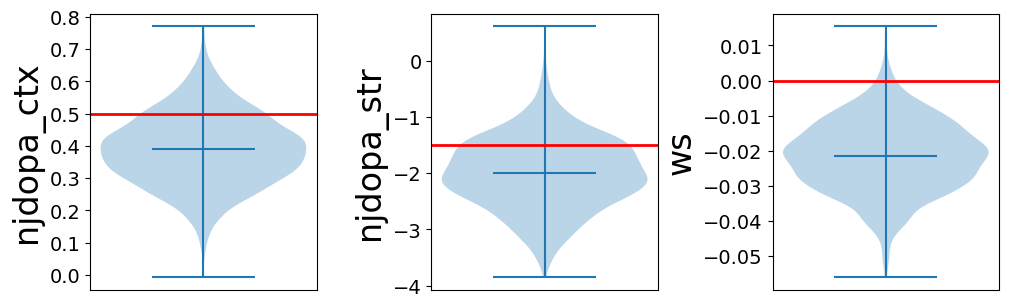

In [36]:
import matplotlib.pyplot as plt
params_label = np.array(['njdopa_ctx', 'njdopa_str', 'ws'])
plt.figure(figsize=(10, 3))
for i, variables in enumerate([njdopa_ctx_est, njdopa_str_est, ws_est]):
    plt.subplot(1,params_label.shape[0],i+1)
    plt.violinplot(variables, widths=0.7, showmeans=True, showextrema=True);
    plt.axhline(y=true_params[i], linewidth=2, color='r')
    plt.ylabel(str(params_label[i]), fontsize=24)   
    plt.xticks([])
    plt.yticks(fontsize=14)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir), "PosteriorViloin_Monbtbrio_NMM_ode_Istep_EstimatedParams_obs.png"), dpi=300)
plt.show()

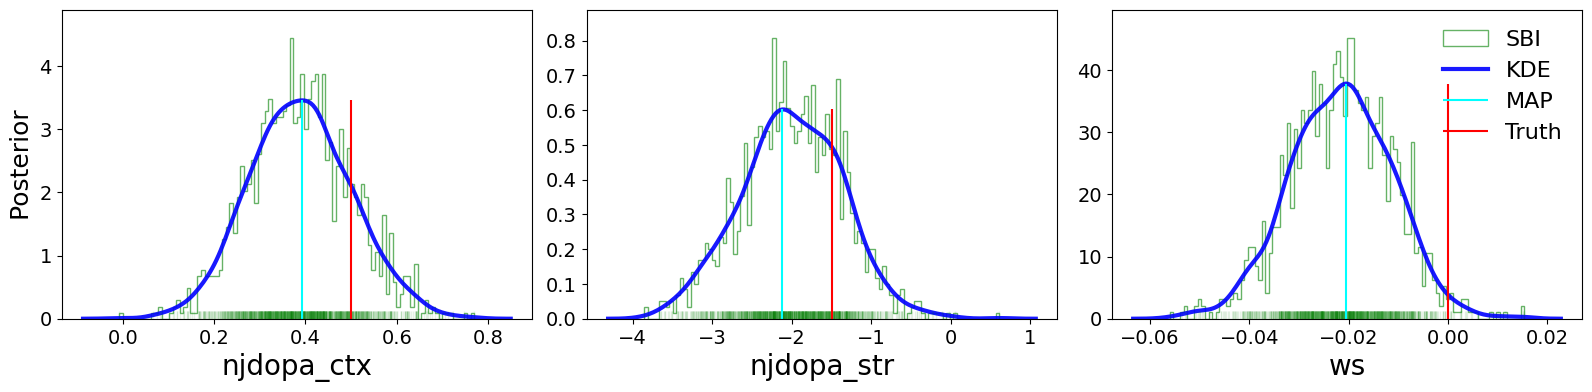

In [37]:
import seaborn as sns
plt.figure(figsize=(16, 4))

for i in range (num_params): 
    ax = plt.subplot(1, 3, i + 1)
    ax=sns.distplot(posterior_samples[:,i], bins=100, hist=True, kde=True, rug=True, rug_kws={"alpha": 0.1, "color": "g"},
                  kde_kws={"color": "b", "alpha": 0.9, "lw": 3, "label": "KDE"},
                  hist_kws={"histtype": "step", "linewidth": 1, "alpha": 0.6, "color": "g"},
                  label='SBI')

    x_ = ax.lines[0].get_xdata()
    y_ = ax.lines[0].get_ydata()
    ymax = max(y_)
    xpos = np.argmax(y_, axis=0)
    xmax = x_[xpos]
    plt.vlines(x=xmax, ymin=0., ymax=y_.max(), colors='cyan', label='MAP')
    plt.vlines(x=true_params[i], ymin=0., ymax=y_.max(), colors='r', label='Truth')

    plt.xlabel(str(params_label[i]), fontsize=20)   
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    if i==0:
        plt.ylabel(' Posterior ', fontsize=18);  
    else:
        plt.ylabel('')
        
    if i==2:
            plt.legend(fontsize=16, frameon=False)
 
plt.tight_layout(pad=1.0)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir), "Posterior_Monbtbrio_NMM_ode_Istep_EstimatedParams_obsI.png"), dpi=300)
plt.show()

In [38]:
prior_samples=np.stack([prior.sample().tolist() for _ in range(1000)], axis=0)
prior_samples.shape

(1000, 3)

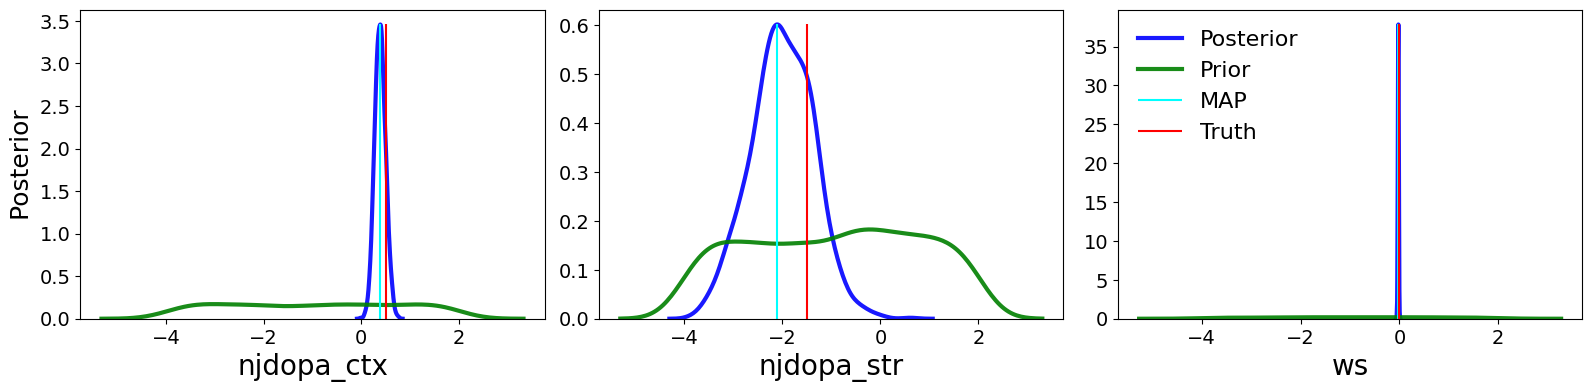

In [39]:
plt.figure(figsize=(16, 4))

for i in range (num_params): 
    ax = plt.subplot(1, 3, i + 1)
    
   
    ax=sns.distplot(posterior_samples[:,i], bins=100, hist=False, kde=True, rug=False, rug_kws={"alpha": 0.1, "color": "g"},
                  kde_kws={"color": "b", "alpha": 0.9, "lw": 3, "label": "Posterior"})
    
    ax_=sns.distplot(prior_samples[:,i], bins=100, hist=False, kde=True, rug=False, rug_kws={"alpha": 0.1, "color": "g"},
                  kde_kws={"color": "g", "alpha": 0.9, "lw": 3, "label": "Prior"})

    x_ = ax.lines[0].get_xdata()
    y_ = ax.lines[0].get_ydata()
    ymax = max(y_)
    xpos = np.argmax(y_, axis=0)
    xmax = x_[xpos]
    plt.vlines(x=xmax, ymin=0., ymax=y_.max(), colors='cyan', label='MAP')
    plt.vlines(x=true_params[i], ymin=0., ymax=y_.max(), colors='r', label='Truth')

    plt.xlabel(str(params_label[i]), fontsize=20)   
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    if i==0:
        plt.ylabel(' Posterior ', fontsize=18);  
    else:
        plt.ylabel('')
        
    if i==2:
            plt.legend(fontsize=16, frameon=False)
 
plt.tight_layout(pad=1.0)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir), "Posterior_Monbtbrio_NMM_ode_Istep_EstimatedParamswithPrior_obsI.png"), dpi=300)
plt.show()

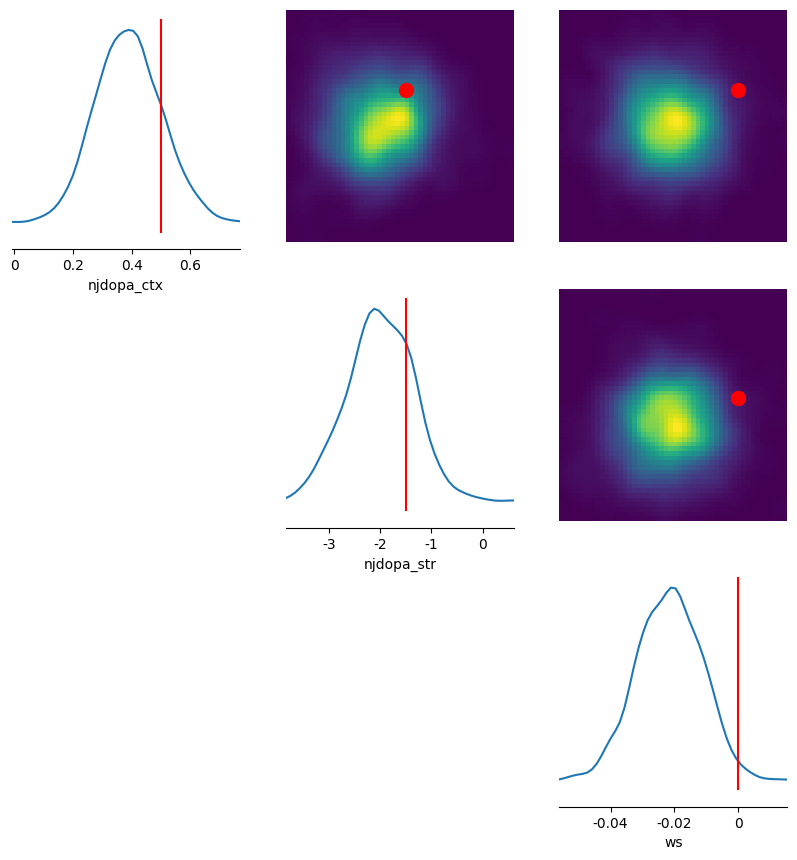

In [40]:
fig, axes = pairplot(posterior_samples,
                           fig_size=(8,8),
                           labels=params_label,
                           upper=['kde'],
                           diag=['kde'],
                           points=true_params,
                           points_offdiag={'markersize': 20},
                           points_colors='r');
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir), "Monbtbrio_NMM_ode_Istep_posterior_pairplot_obsI.png"), dpi=300)
plt.show()

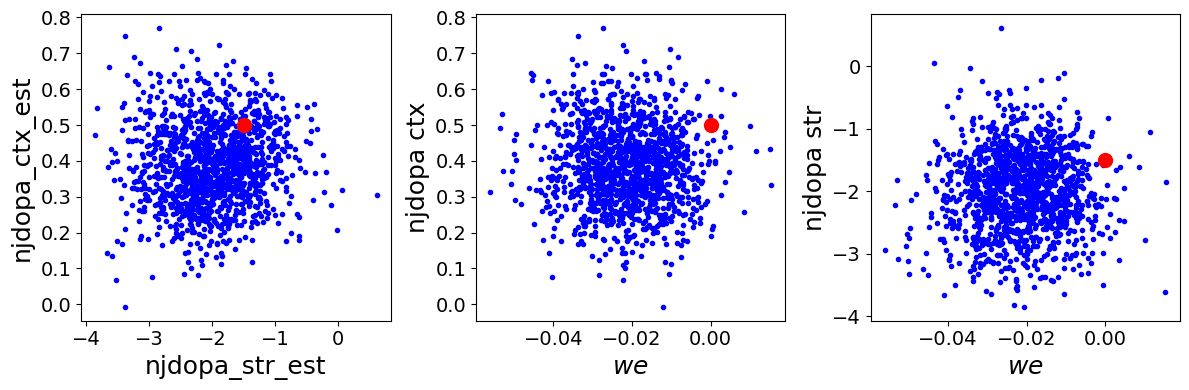

In [41]:
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.plot(njdopa_str_est, njdopa_ctx_est,'.', color='blue')
plt.plot(njdopa_str_true, njdopa_ctx_true,'o', color='red', markersize=10)
plt.xlabel("njdopa_str_est", fontsize=18)
plt.ylabel("njdopa_ctx_est", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.subplot(132)
plt.plot(ws_est, njdopa_ctx_est, '.',color='blue')
plt.plot(ws_true, njdopa_ctx_true, 'o', color='red', markersize=10)
plt.xlabel("$we$", fontsize=18)
plt.ylabel("njdopa ctx",fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.subplot(133)
plt.plot(ws_est, njdopa_str_est, '.', color='blue')
plt.plot(ws_true, njdopa_str_true, 'o', color='red', markersize=10)
plt.xlabel("$we$", fontsize=18)
plt.ylabel("njdopa str", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir), "Monbtbrio_NMM_ode_Istep_posterior_PairParamsJoindist_obsI.png"), dpi=300)
plt.show()

## Posterior Predictive Check preparation 

In [270]:
ppc_feat = 'VAR_FCD' #'Left-Caudate_Whole_ALFF'
ppc_theta_and_features_df = theta_and_features_df[theta_and_features_df[ppc_feat]==theta_and_features_df[theta_and_features_df['njdopa_str']<=4][ppc_feat].max()]

In [289]:
true_params

array([[0.75 , 1.   , 0.318]])

In [290]:
x_obs_summary_statistics = ppc_theta_and_features_df.loc[:,selected_features].values
true_params = ppc_theta_and_features_df.loc[:, selected_params].values[0]
njdopa_ctx_true = true_params[0]
njdopa_str_true = true_params[1]
we_true = true_params[2]
true_params

array([0.75 , 1.   , 0.318])

In [285]:
posterior_samples = posterior.sample((theta_and_features_df.shape[0],), x_obs_summary_statistics).numpy()
posterior_samples.shape

Drawing 5718 posterior samples: 5922it [00:00, 111333.74it/s]           


(5718, 3)

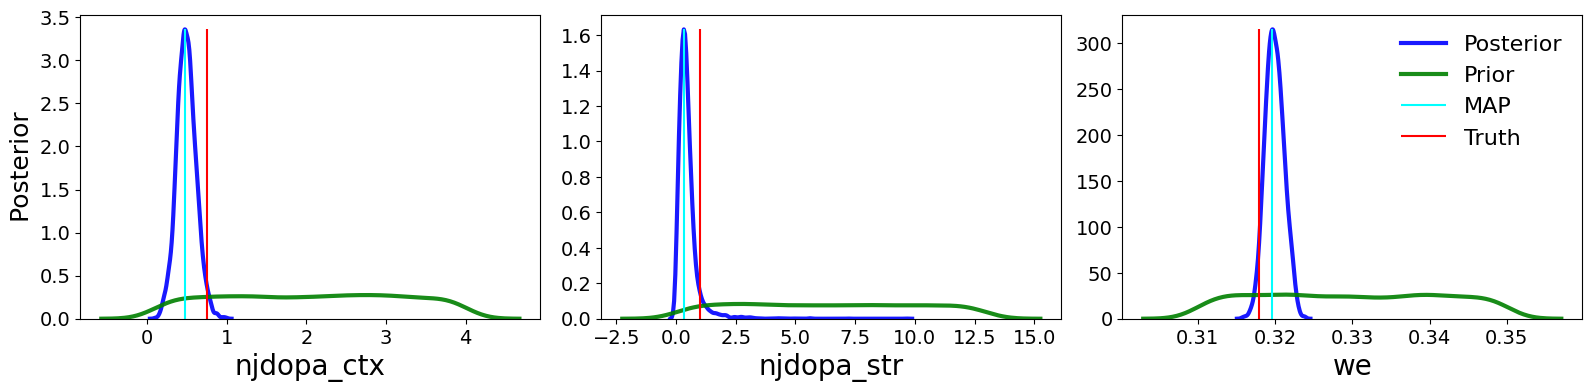

In [292]:
params_label = np.array(['njdopa_ctx', 'njdopa_str', 'we'])

plt.figure(figsize=(16, 4))

for i in range (num_params): 
    ax = plt.subplot(1, 3, i + 1)
    
   
    ax=sns.distplot(posterior_samples[:,i], bins=100, hist=False, kde=True, rug=False, rug_kws={"alpha": 0.1, "color": "g"},
                  kde_kws={"color": "b", "alpha": 0.9, "lw": 3, "label": "Posterior"})
    
    ax_=sns.distplot(prior_samples[:,i], bins=100, hist=False, kde=True, rug=False, rug_kws={"alpha": 0.1, "color": "g"},
                  kde_kws={"color": "g", "alpha": 0.9, "lw": 3, "label": "Prior"})

    x_ = ax.lines[0].get_xdata()
    y_ = ax.lines[0].get_ydata()
    ymax = max(y_)
    xpos = np.argmax(y_, axis=0)
    xmax = x_[xpos]
    plt.vlines(x=xmax, ymin=0., ymax=y_.max(), colors='cyan', label='MAP')
    plt.vlines(x=true_params[i], ymin=0., ymax=y_.max(), colors='r', label='Truth')

    plt.xlabel(str(params_label[i]), fontsize=20)   
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    if i==0:
        plt.ylabel(' Posterior ', fontsize=18);  
    else:
        plt.ylabel('')
        
    if i==2:
            plt.legend(fontsize=16, frameon=False)
 
plt.tight_layout(pad=1.0)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir), "Posterior_Monbtbrio_NMM_ode_Istep_EstimatedParamswithPrior_obsI.png"), dpi=300)
plt.show()

In [299]:
import random 
ppc_post_samples = posterior_samples[np.random.choice(posterior_samples.shape[0], 100)]
ppc_post_samples_df = pd.DataFrame(data=ppc_post_samples, columns=params_label)
ppc_post_samples_df.to_csv('ppc_post_samples_df.csv')
ppc_post_samples_df.head()

,njdopa_ctx,njdopa_str,we
0,0.485604,0.493869,0.319794
1,0.429098,0.666548,0.319744
2,0.443623,0.370230,0.319721
3,0.596410,0.196927,0.320831
4,0.633018,0.664518,0.319177


In [331]:
ppc_theta_and_features_df[ALFF_features].shape[1]

17

In [300]:
# After running simulations...

In [340]:
results_to_plot[ALFF_features].columns.to_list()

['Left-Putamen_Whole_ALFF',
 'Left-Putamen_Slow-5_ALFF',
 'Left-Putamen_Slow-4_ALFF',
 'Left-Putamen_Slow-3_ALFF',
 'Right-Putamen_Whole_ALFF',
 'Right-Putamen_Slow-5_ALFF',
 'Right-Putamen_Slow-4_ALFF',
 'Right-Putamen_Slow-3_ALFF',
 'Left-Caudate_Whole_ALFF',
 'Left-Caudate_Slow-5_ALFF',
 'Left-Caudate_Slow-4_ALFF',
 'Left-Caudate_Slow-3_ALFF',
 'Right-Caudate_Whole_ALFF',
 'Right-Caudate_Slow-5_ALFF',
 'Right-Caudate_Slow-4_ALFF',
 'Right-Caudate_Slow-3_ALFF',
 'VAR_FCD']

In [356]:
import seaborn as sns

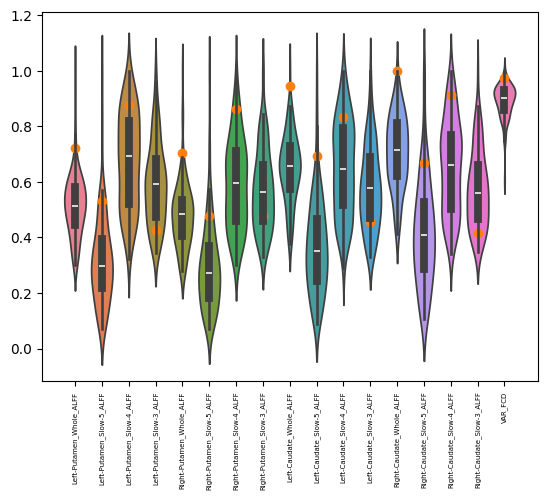

In [360]:
results_to_plot = pd.read_csv("snakemake/analyse_results/ppc_alff_we_Jdopactx_Jdopastr.csv")
sns.violinplot(results_to_plot[ALFF_features]/results_to_plot[ALFF_features].max())
plt.scatter(np.arange(0,ppc_theta_and_features_df[ALFF_features].shape[1],1), ppc_theta_and_features_df[ALFF_features]/results_to_plot[ALFF_features].max())
plt.xticks(np.arange(0,ppc_theta_and_features_df[ALFF_features].shape[1],1), labels=results_to_plot[ALFF_features].columns.to_list(), rotation=90, size=5)
plt.show()

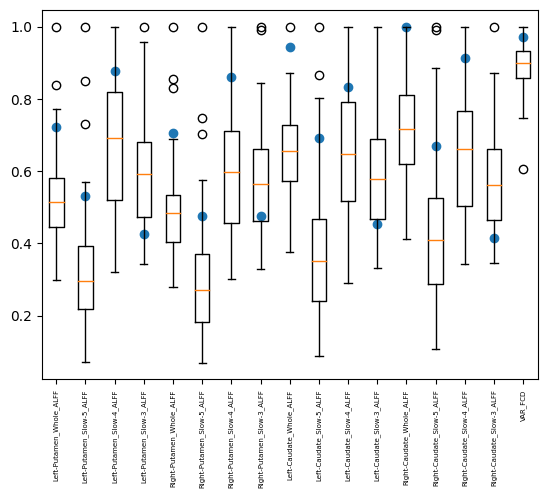

In [354]:
results_to_plot = pd.read_csv("snakemake/analyse_results/ppc_alff_we_Jdopactx_Jdopastr.csv")
NON_alff_features = ['GBC', 'Limbic_LH_Default_Par_1', 'Vis_mean_within']
ALFF_features = [f for f in selected_features if f not in NON_alff_features]
plt.boxplot(results_to_plot[ALFF_features]/results_to_plot[ALFF_features].max())
plt.scatter(np.arange(0,ppc_theta_and_features_df[ALFF_features].shape[1],1)+1, ppc_theta_and_features_df[ALFF_features]/results_to_plot[ALFF_features].max())
plt.xticks(np.arange(0,ppc_theta_and_features_df[ALFF_features].shape[1],1)+1, labels=results_to_plot[ALFF_features].columns.to_list(), rotation=90, size=5)
plt.show()

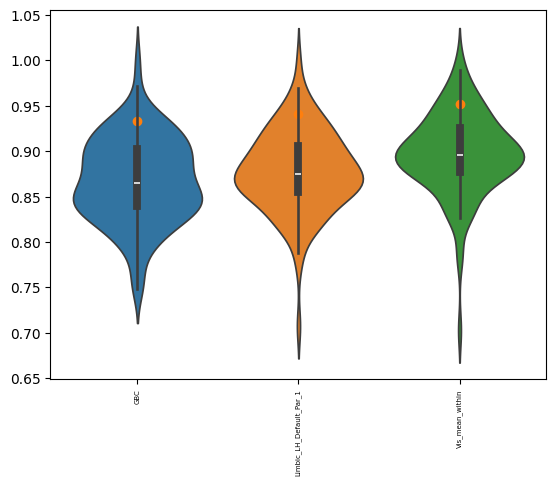

In [362]:
results_to_plot = pd.read_csv("snakemake/analyse_results/ppc_fisher_fc_we_Jdopactx_Jdopastr.csv")
NON_alff_features = ['GBC', 'Limbic_LH_Default_Par_1', 'Vis_mean_within']
ALFF_features = [f for f in selected_features if f not in NON_alff_features]
sns.violinplot(results_to_plot[NON_alff_features]/results_to_plot[NON_alff_features].max())
plt.scatter(np.arange(0,ppc_theta_and_features_df[NON_alff_features].shape[1],1), ppc_theta_and_features_df[NON_alff_features]/results_to_plot[NON_alff_features].max())
plt.xticks(np.arange(0,ppc_theta_and_features_df[NON_alff_features].shape[1],1), labels=results_to_plot[NON_alff_features].columns.to_list(), rotation=90, size=5)
plt.show()

## Evaluating performance of SBI 

In [42]:
theta_and_errors = []

In [43]:
from scipy.stats import gaussian_kde

true_params_batch = test_theta_df.values.astype(float)
x_obs_batch = test_datafeat_df.values.astype(np.float32)

n_obs = x_obs_batch.shape[0]
n_samples = 3000

prior_samples = np.stack(
    [prior.sample().tolist() for _ in range(3000)],
    axis=0
)

theta_and_errors = np.zeros((n_obs, 21))  # 7 blocks × 3 params

for i in range(n_obs):

    x_obs = torch.tensor(x_obs_batch[i], dtype=torch.float32)

    posterior_samples = posterior.sample(
        (n_samples,),
        x=x_obs
    ).numpy()

    # --- MAP estimate via KDE ---
    est_params = []
    for j in range(3):
        try:
            kde = gaussian_kde(posterior_samples[:, j])
            x_vals = np.linspace(
                posterior_samples[:, j].min(),
                posterior_samples[:, j].max(),
                500
            )
            y_vals = kde(x_vals)
            est_param_j = x_vals[np.argmax(y_vals)]
        except np.linalg.LinAlgError:
            est_param_j = np.median(posterior_samples[:, j])

        est_params.append(est_param_j)

    est_params = np.array(est_params)

    true_params = true_params_batch[i, :3]

    # --- Posterior mean & std ---
    posterior_mean = np.mean(posterior_samples[:, :3], axis=0)
    posterior_std  = np.std(posterior_samples[:, :3], axis=0)

    # --- Metrics ---
    error = np.abs(true_params - est_params) / np.maximum(np.abs(true_params), 1e-8)

    zscores = np.abs(true_params - est_params) / np.maximum(posterior_std, 1e-8)

    shrink = 1 - (
        np.var(posterior_samples[:, :3], axis=0) /
        np.var(prior_samples[:, :3], axis=0)
    )

    # --- Store everything ---
    theta_and_errors[i] = np.concatenate([
        true_params,
        est_params,
        error,
        zscores,
        shrink,
        posterior_mean,
        posterior_std
    ])

Drawing 3000 posterior samples: 3341it [00:00, 67677.84it/s]            
Drawing 3000 posterior samples: 3409it [00:00, 23621.08it/s]                          
Drawing 3000 posterior samples: 3042it [00:00, 26964.75it/s]                          
Drawing 3000 posterior samples: 3167it [00:00, 28972.92it/s]            
Drawing 3000 posterior samples: 3082it [00:00, 26976.28it/s]                          
Drawing 3000 posterior samples: 3099it [00:00, 28458.09it/s]                          
Drawing 3000 posterior samples: 3161it [00:00, 28523.23it/s]            
Drawing 3000 posterior samples: 3272it [00:00, 20638.63it/s]                          
Drawing 3000 posterior samples: 4141it [00:00, 29820.28it/s]                        
Drawing 3000 posterior samples: 3835it [00:00, 30452.78it/s]                          
Drawing 3000 posterior samples: 3099it [00:00, 27874.24it/s]                          
Drawing 3000 posterior samples: 3087it [00:00, 26042.72it/s]                          


In [44]:
param_names = selected_params
columns = (
    [f"true_{p}" for p in param_names] +
    [f"est_{p}" for p in param_names] +
    [f"rel_err_{p}" for p in param_names] +
    [f"zscore_{p}" for p in param_names] +
    [f"shrink_{p}" for p in param_names] +
    [f"post_mean_{p}" for p in param_names] +
    [f"post_std_{p}" for p in param_names]
)

errdf = pd.DataFrame(theta_and_errors, columns=columns)
errdf.to_csv('zscores_shrink_errors.csv')
rederrdf = errdf.copy()
#rederrdf = rederrdf[(rederrdf['rel_err_njdopa_str']<=.1) & (rederrdf['rel_err_njdopa_ctx']<0.2)]

In [45]:
errdf.columns

Index(['true_njdopa_ctx', 'true_njdopa_str', 'true_ws', 'est_njdopa_ctx',
       'est_njdopa_str', 'est_ws', 'rel_err_njdopa_ctx', 'rel_err_njdopa_str',
       'rel_err_ws', 'zscore_njdopa_ctx', 'zscore_njdopa_str', 'zscore_ws',
       'shrink_njdopa_ctx', 'shrink_njdopa_str', 'shrink_ws',
       'post_mean_njdopa_ctx', 'post_mean_njdopa_str', 'post_mean_ws',
       'post_std_njdopa_ctx', 'post_std_njdopa_str', 'post_std_ws'],
      dtype='object')

Text(0, 0.5, 'zscore_ws')

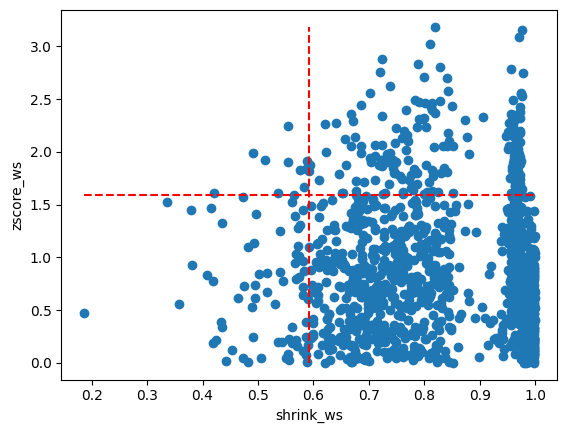

In [90]:
xplot = 'shrink_ws'
yplot = 'zscore_ws'
plt.scatter(rederrdf[xplot], rederrdf[yplot])
plt.vlines(np.abs(rederrdf[xplot].min()+rederrdf[xplot].max())/2, ymin=rederrdf[yplot].min(), ymax=rederrdf[yplot].max(), color='red', linestyle='--')
plt.hlines(np.abs(rederrdf[yplot].min()-rederrdf[yplot].max())/2, xmin=rederrdf[xplot].min(), xmax=rederrdf[xplot].max(), color='red', linestyle='--')
plt.xlabel(xplot)
plt.ylabel(yplot)

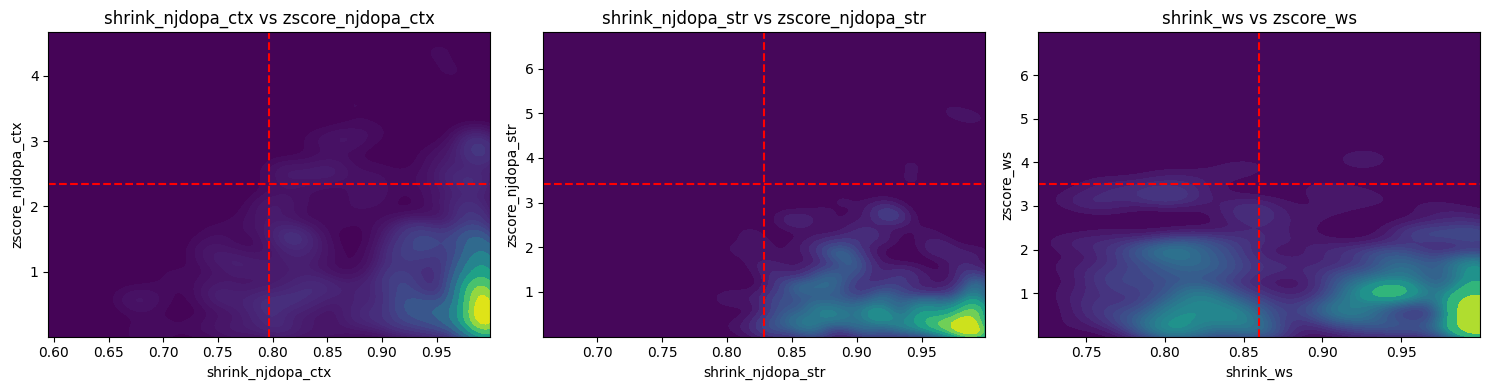

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

xplot1, yplot1, xplot2, yplot2, xplot3, yplot3 = 'shrink_njdopa_ctx', 'zscore_njdopa_ctx', 'shrink_njdopa_str','zscore_njdopa_str', 'shrink_ws', 'zscore_ws', 
# If you want to loop over different variable pairs:
pairs = [
    (xplot1, yplot1),
    (xplot2, yplot2),
    (xplot3, yplot3)
]

for ax, (xplot, yplot) in zip(axes, pairs):

    sns.kdeplot(
        data=rederrdf,
        x=xplot,
        y=yplot,
        fill=True,
        cmap="viridis",
        bw_adjust=0.5,
        levels=20,
        thresh=0,
        cut=0,
        ax=ax
    )

    # Reference lines
    ax.axvline(
        (rederrdf[xplot].min() + rederrdf[xplot].max()) / 2,
        color='red', linestyle='--'
    )
    ax.axhline(
        (rederrdf[yplot].min() + rederrdf[yplot].max()) / 2,
        color='red', linestyle='--'
    )

    ax.set_xlabel(xplot)
    ax.set_ylabel(yplot)
    ax.set_title(f"{xplot} vs {yplot}")

plt.tight_layout()
plt.show()

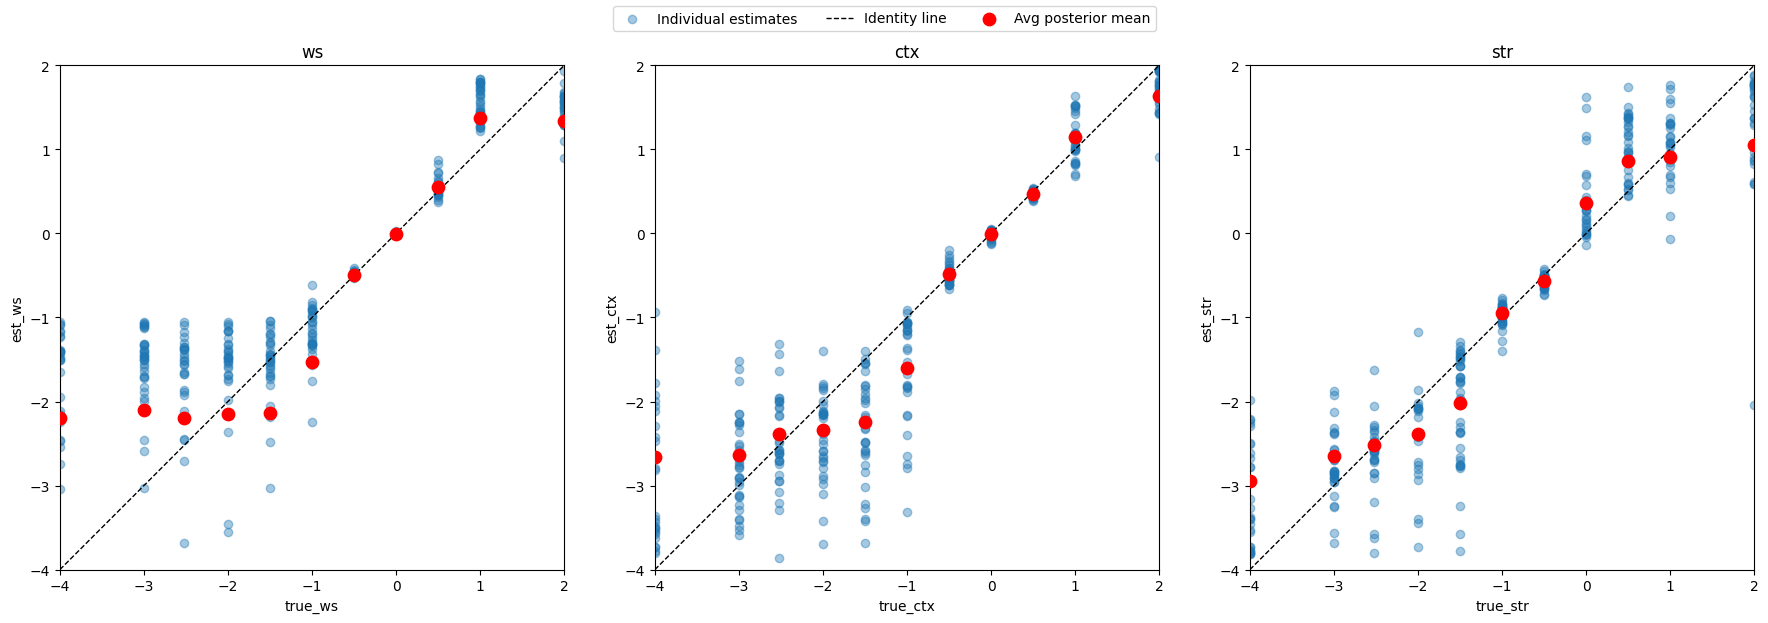

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

params = [
    ("ws", "true_ws", "est_ws", "post_mean_ws"),
    ("ctx", "true_njdopa_ctx", "est_njdopa_ctx", "post_mean_njdopa_ctx"),
    ("str", "true_njdopa_str", "est_njdopa_str", "post_mean_njdopa_str"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, true_col, est_col, postmean_col) in zip(axes, params):

    x = rederrdf[true_col].values
    y = rederrdf[est_col].values

    # Scatter
    scatter = ax.scatter(x, y, alpha=0.4, label="Individual estimates")

    # Identity line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())

    identity = ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Identity line"
    )[0]

    # Grouped posterior mean
    grouped_means = (
        rederrdf
        .groupby(true_col)[postmean_col]
        .mean()
        .reset_index()
    )

    redpoints = ax.scatter(
        grouped_means[true_col],
        grouped_means[postmean_col],
        color="red",
        s=80,
        zorder=5,
        label="Avg posterior mean"
    )

    # Equal scaling
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(f"true_{name}")
    ax.set_ylabel(f"est_{name}")
    ax.set_title(name)

# --- Single shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Text(0.5, 0.92, 'Errors between real and predicted params')

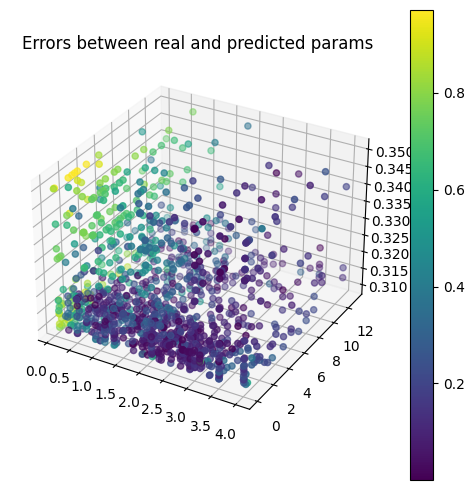

In [35]:
x = rederrdf['true_njdopa_ctx']
y = rederrdf['true_njdopa_str']
z = rederrdf['true_we']
c = rederrdf['rel_err_njdopa_ctx']

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, z, c=c)
cbar = plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.title("Errors between real and predicted params")

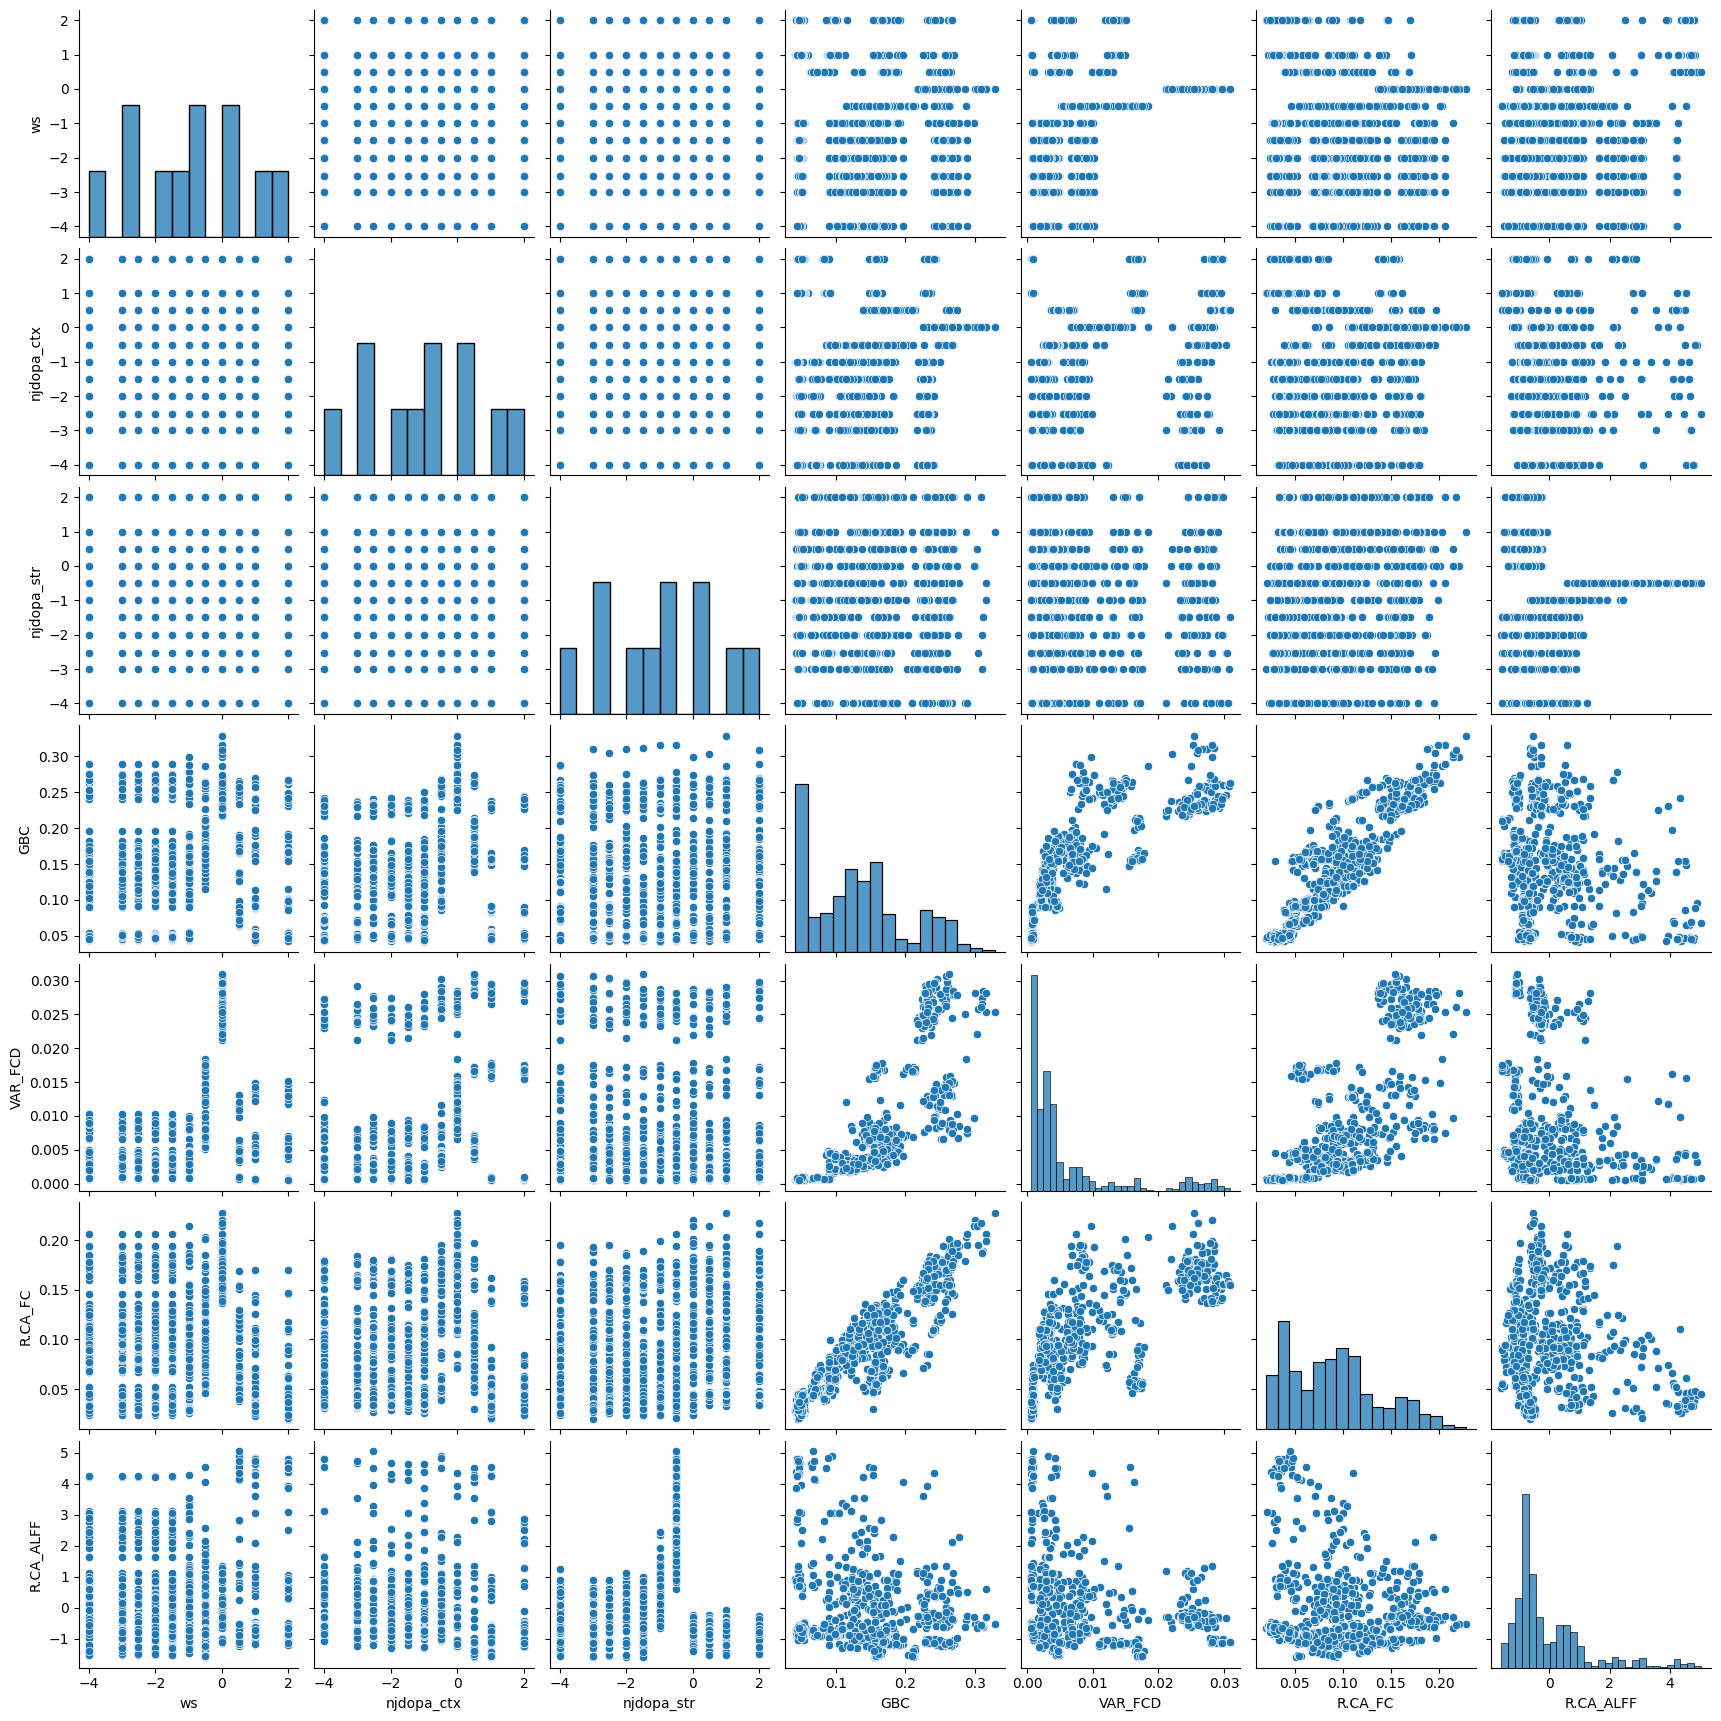

In [95]:
select_columns = ['ws', 'njdopa_ctx', 'njdopa_str', 'GBC', 'VAR_FCD', 'R.CA_FC', 'R.CA_ALFF']

sns.pairplot(theta_and_features_df[select_columns])